# Chapter 14 — Counting

Multiplying choices, and telling permutations from combinations.

| Section | What it covers |
|---|---|
| 14.1 | The multiplication rule |
| 14.2 | Permutations and combinations |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Counting](https://khh-aka-lucifer.github.io/statLab/chapters/counting/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## Why counting is a statistics problem

Every probability of the form "favourable outcomes over total outcomes" needs you to count both.
Counting sounds like the easy part and it is where most mistakes happen.

We will use `math.comb` and `math.perm`, which are in the standard library, and check every formula
against brute force on a small case.

In [2]:
import math
from itertools import permutations, combinations, product

print(f"math.comb(5, 2) = {math.comb(5, 2)}")
print(f"math.perm(5, 2) = {math.perm(5, 2)}")

math.comb(5, 2) = 10
math.perm(5, 2) = 20


## 14.1 The multiplication rule

If one choice has $a$ options and a second independent choice has $b$ options, together they have
$a \times b$. Most counting is this rule applied repeatedly.

In [3]:
shirts, trousers, shoes = ["white", "blue", "grey"], ["jeans", "chinos"], ["boots", "trainers"]

outfits = list(product(shirts, trousers, shoes))

print(f"{len(shirts)} x {len(trousers)} x {len(shoes)} = {len(shirts)*len(trousers)*len(shoes)}")
print(f"actually listed: {len(outfits)}")
print()
for outfit in outfits[:4]:
    print("   ", ", ".join(outfit))
print("    ...")

3 x 2 x 2 = 12
actually listed: 12

    white, jeans, boots
    white, jeans, trainers
    white, chinos, boots
    white, chinos, trainers
    ...


The formula and the list agree, which is the habit worth forming. Whenever a counting formula feels
shaky, list the small case and count the rows.

Here is the rule on real data. The penguin file records three species, three islands and two sexes,
so how many combinations could exist, and how many actually do?

In [4]:
penguins = pd.read_csv(DATA / "penguins.csv")
clean = penguins.dropna(subset=["sex"])

possible = clean["species"].nunique() * clean["island"].nunique() * clean["sex"].nunique()
actual = clean.groupby(["species", "island", "sex"]).size()

print(f"multiplication rule says: 3 x 3 x 2 = {possible} combinations")
print(f"combinations that actually occur: {len(actual)}")
print()
print(actual.to_string())

multiplication rule says: 3 x 3 x 2 = 18 combinations
combinations that actually occur: 10

species    island     sex   
Adelie     Biscoe     FEMALE    22
                      MALE      22
           Dream      FEMALE    27
                      MALE      28
           Torgersen  FEMALE    24
                      MALE      23
Chinstrap  Dream      FEMALE    34
                      MALE      34
Gentoo     Biscoe     FEMALE    58
                      MALE      61


Ten of the eighteen. The multiplication rule counts what is *possible* under free combination, and
the world is not free: Chinstrap penguins live only on Dream, and Gentoo only on Biscoe.

That gap between possible and observed is not a failure of the arithmetic. It is a finding about
penguins.

In [ ]:
# Your turn.
# The Titanic file has class (3), sex (2) and embark_town (3).
# 1. How many combinations does the multiplication rule allow?
# 2. How many actually occur in the data?
# 3. List any that are missing. Is the absence interesting or just a small sample?

titanic = pd.read_csv(DATA / "titanic.csv")
...

## 14.2 Permutations and combinations

The question that decides which formula you need is always the same: **does order matter?**

A **permutation** counts arrangements, where order matters, and there are
$P(n,k) = \frac{n!}{(n-k)!}$ ways to arrange $k$ of $n$ things.

A **combination** counts selections, where order does not, and there are
$C(n,k) = \binom{n}{k} = \frac{n!}{k!(n-k)!}$ ways to choose $k$ of $n$.

Every combination corresponds to $k!$ permutations, which is the whole difference.

In [5]:
people = ["Ana", "Ben", "Cleo", "Dev", "Eli"]
k = 3

perms = list(permutations(people, k))
combs = list(combinations(people, k))

print(f"arrangements of {k} from {len(people)}: formula {math.perm(len(people), k):3d}, listed {len(perms):3d}")
print(f"selections   of {k} from {len(people)}: formula {math.comb(len(people), k):3d}, listed {len(combs):3d}")
print(f"ratio = {len(perms) / len(combs):.0f}, which is {k}! = {math.factorial(k)}")
print()
print("the first selection, and all the arrangements it hides:")
print("   ", combs[0])
for p in perms[:6]:
    print("       ", p)

arrangements of 3 from 5: formula  60, listed  60
selections   of 3 from 5: formula  10, listed  10
ratio = 6, which is 3! = 6

the first selection, and all the arrangements it hides:
    ('Ana', 'Ben', 'Cleo')
        ('Ana', 'Ben', 'Cleo')
        ('Ana', 'Ben', 'Dev')
        ('Ana', 'Ben', 'Eli')
        ('Ana', 'Cleo', 'Ben')
        ('Ana', 'Cleo', 'Dev')
        ('Ana', 'Cleo', 'Eli')


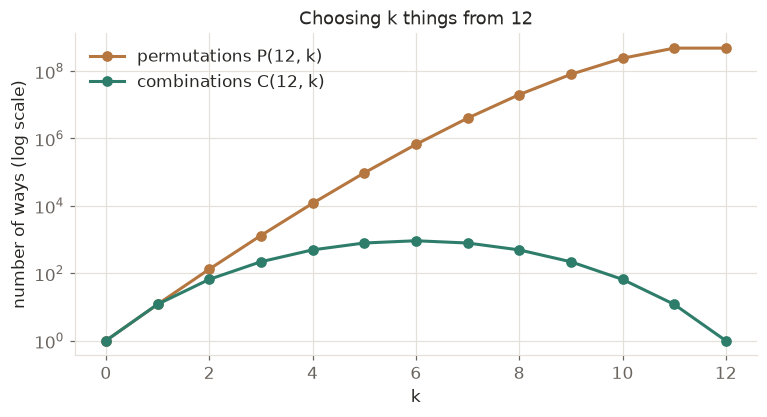

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.8))
n = 12
ks = np.arange(0, n + 1)

ax.plot(ks, [math.perm(n, k) for k in ks], "o-", color=C["cat2"], lw=2, ms=6,
        label="permutations P(12, k)")
ax.plot(ks, [math.comb(n, k) for k in ks], "o-", color=C["accent"], lw=2, ms=6,
        label="combinations C(12, k)")
ax.set_yscale("log")

ax.set_xlabel("k"); ax.set_ylabel("number of ways (log scale)")
ax.set_title("Choosing k things from 12")
ax.legend()
plt.show()

Combinations are symmetric, because choosing 3 to keep is the same as choosing 9 to leave. They peak
in the middle. Permutations just keep climbing, because every extra item multiplies the arrangements.

### Counting connects back to Chapter 1

How many different samples of 30 could we have drawn from those 342 weighed penguins? Chapter 1
talked about "another sample" as if it were one alternative. It is rather more.

In [7]:
total, sample_size = 342, 30
ways = math.comb(total, sample_size)

print(f"C(342, 30) = {ways:,}")
print(f"which is about 10^{math.log10(ways):.0f}")
print()
print(f"atoms in the observable universe: about 10^80")

C(342, 30) = 10,669,055,792,741,389,053,980,547,408,374,178,783,057,624
which is about 10^43

atoms in the observable universe: about 10^80


Every one of those samples would have given a different $\bar{x}$. The sampling distribution from
Chapter 1 is the distribution over that unimaginable set, and simulating a thousand of them is a
tiny peek at it. That is why the theory matters: you cannot enumerate your way there.

### The birthday problem

The classic surprise, and a good exercise in counting the complement instead of the event.

In [8]:
def birthday_probability(n):
    # easier to count the ways everyone DIFFERS, then subtract
    return 1 - math.perm(365, n) / 365**n

for n in [10, 23, 40, 60, 70]:
    print(f"{n:3d} people -> P(a shared birthday) = {birthday_probability(n):.4f}")

# check by simulation, because a surprising answer deserves a second opinion
n = 23
hits = sum(len(set(rng.integers(0, 365, n))) < n for _ in range(20_000))
print(f"\nsimulated at n = 23: {hits/20_000:.4f}")

 10 people -> P(a shared birthday) = 0.1169
 23 people -> P(a shared birthday) = 0.5073
 40 people -> P(a shared birthday) = 0.8912
 60 people -> P(a shared birthday) = 0.9941
 70 people -> P(a shared birthday) = 0.9992



simulated at n = 23: 0.5093


In [ ]:
# Your turn.
# A national lottery asks you to pick 6 numbers from 49.
# 1. How many tickets are possible?
# 2. What is the probability that one ticket wins?
# 3. If a ticket costs 1 unit, how much would it cost to buy every combination?
# 4. Now do the same for "pick 5 from 50 plus 2 from 12", which is how EuroMillions works.

...

## Exercises

1. **Order matters, sometimes.** A race with 8 runners awards gold, silver and bronze. How many
   podiums are possible? Now how many *sets* of three medallists? Explain the ratio.

2. **Poker.** Count the 5-card hands from a 52-card deck, then count how many are a flush (all one
   suit). Compute the probability. Verify by dealing a million simulated hands.

3. **Pascal's triangle.** Build the first 15 rows using `math.comb`, then confirm that each entry is
   the sum of the two above it, and that row $n$ adds to $2^n$.

4. **Sampling with and without replacement.** Chapter 1 sampled without replacement. How many ordered
   samples of 30 from 342 are there *with* replacement? Compare it against $C(342,30)$ and explain
   the gap.

5. **The birthday problem, extended.** Find the smallest $n$ for which the probability of a shared
   birthday exceeds 0.99. Then redo it for a year of 1000 days and see how the answer scales.

## What you should take away

Multiply independent choices, and always sanity-check a formula by listing a small case. The one
question that picks the formula is whether order matters, and permutations exceed combinations by
exactly $k!$ because that is how many orderings each selection hides.

Counting also explains why sampling theory is necessary rather than optional. There are about
$10^{45}$ possible samples of 30 penguins, so no amount of computing will enumerate them, and a
distribution is the only way to describe what they would say.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*